# Map of Magnetometers on the Irish Island

In [34]:
from apexpy import Apex
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from magie.Plotting_Tools import contour_labels, add_land, add_ocean
import matplotlib
from magie.Rotate2Geo import Huber_Mean
import matplotlib.cm as cm
import secsy.cubedsphere as cs
# plt.style.use('dark_background')

## Create Grid

In [35]:
A= Apex(pd.Timestamp('2024-11-11T10:00'))
longlim= 15, 5
latlim= 45, 65
lon_centre, lat_centre= 352, 53.4
f1, f2 = A.basevectors_qd(lat_centre, lon_centre, 0, coords = 'geo')
qd_north = f2 / np.linalg.norm(f2)
East, North= qd_north[0], qd_north[1]
Gridproj= cs.CSprojection((lon_centre, lat_centre), np.rad2deg(np.arctan2(East, North)))
node_grid= cs.CSgrid(Gridproj, 400, 500, 10., 10.)

In [36]:
cs.CSgrid?

Init signature: cs.CSgrid(projection, L, W, Lres, Wres, edges=None, wshift=0, R=6371.2)
Docstring:      <no docstring>
Init docstring:
set up grid for cubed sphere projection 

Create a regular grid in xi,eta-coordinates. The grid will cover a 
region of the cube surface that is L by W, where L is the dimension along
the projection.orientation vector. The center of the grid is located at
projection.position. 

Parameters
----------
projection: CSprojection
    CSprojection
L: float
    Dimension of grid along CSprojection.orientation, i.e. the "length"
    of the grid. Dimension corresponds to the dimension of R at the 
    cube-sphere intersection point
W: float
    Dimension of grid perpendicular CSprojection.orientation, i.e. the 
    "width" of the grid. Dimension corresponds to the dimension of R at 
    the cube-sphere intersection point 
Lres: float or int
    If float, Lres denotes the size of grid cells in L direction, with 
    dimension same as R (at cube-sphere intersection

## Create Figure

(np.float64(-0.031350113539963184),
 np.float64(0.02986279450590227),
 np.float64(-0.039158816741839075),
 np.float64(0.03774970875168418))

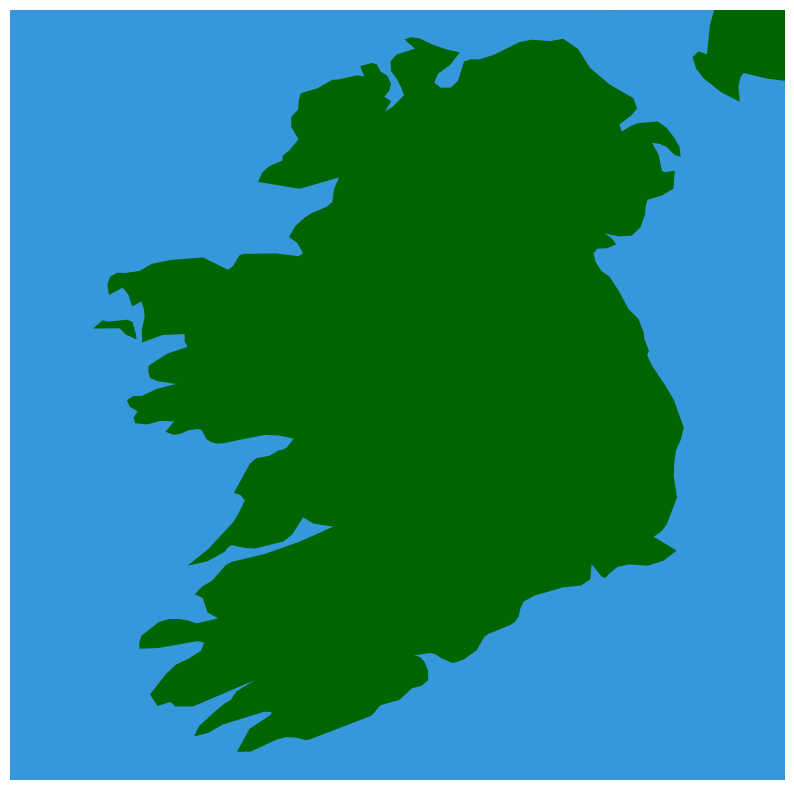

In [37]:
fig = plt.figure(figsize=(10, 10))
gs= fig.add_gridspec(1, 1, hspace=0, wspace=0.1)
map_ax= fig.add_subplot(gs[0, 0])

add_land(map_ax, node_grid)
add_ocean(map_ax, node_grid)
map_ax.set_xlim(node_grid.xi_min, node_grid.xi_max)
map_ax.set_ylim(node_grid.eta_min, node_grid.eta_max)
map_ax.axis('off')

## Add Magnetic Co-ordinates

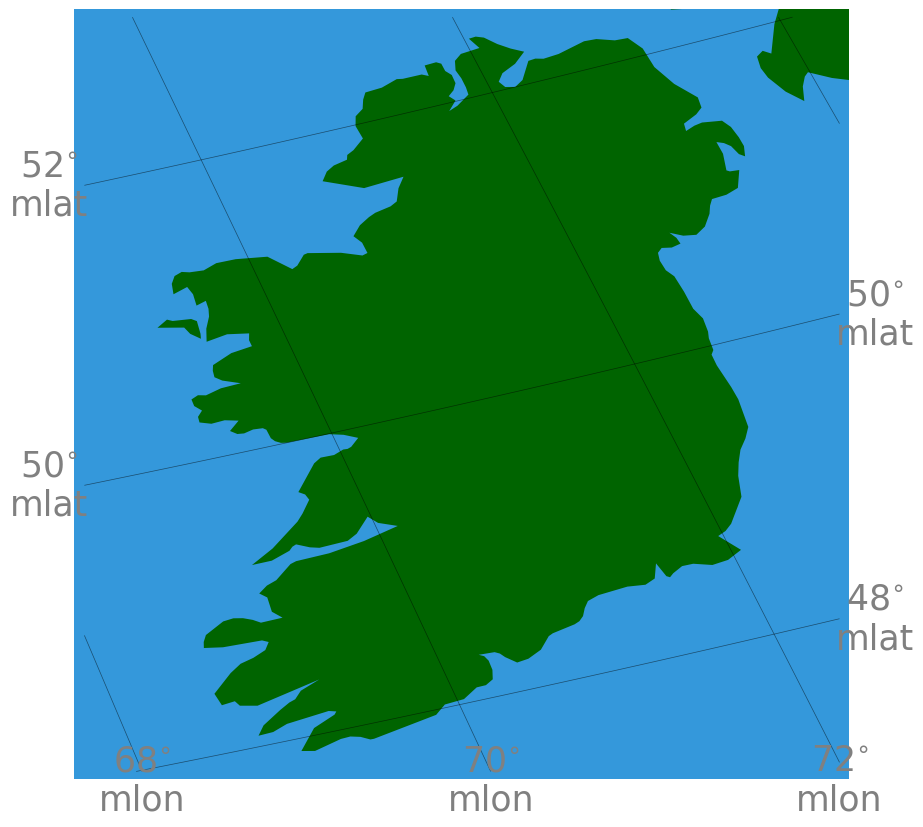

In [38]:
mlat, mlon= A.convert(node_grid.lat, node_grid.lon, source='GEO', dest='qd', datetime=pd.Timestamp('2024-11-11T10:00'), height=80)
mlon[mlon>360]-=360
clon=map_ax.contour(node_grid.xi, node_grid.eta, mlon, levels = np.r_[0:360:2], colors = 'black', alpha=.5, linewidths=.5)
clat=map_ax.contour(node_grid.xi, node_grid.eta, mlat, levels = np.r_[-90:90:2], colors = 'black', alpha=.5, linewidths=.5)
map_ax.clon=contour_labels(clon, fmt=lambda x: f'{int(x)}'+r'$^{\circ}$'+'\nmlon', sides=['bottom'], xpad=.06, ypad=.0001, size=25,
                            color='grey')
map_ax.clat=contour_labels(clat, fmt=lambda x: f'{int(x)}'+r'$^{\circ}$'+'\nmlat', xpad=.002, ypad=.07, sides=['left', 'right'], size=25,
                            color='grey')
fig

## Set Site Names and Location

In [39]:
dun_glat = 53.38  # Dunsink Observatory latitude
dun_glon = 353.66  # Dunsink Observatory longitude

val_glat = 51.94  # Valentia Observatory latitude
val_glon = 349.76  # Valentia Observatory longitude

arm_glat = 54.34  # Armagh Observatory latitude
arm_glon = 353.34  # Armagh Observatory longitude


bir_glat= 53.10  # Birr Castle latitude
bir_glon= 352.09  # Birr Castle longitude

flo_glat= 54.26  # Florence Court latitude
flo_glon= 352.28  # Florence Court longitude

mal_glat= 55.37186838460114  # Malin Head latitude
mla_glon= 352.67  # Malin Head longitude
mag_locs= pd.DataFrame({
    'name': ['Dunsink', 'Valentia', 'Armagh', 'Birr', 'Florence Court', 'Malin Head'],
    'glat': [dun_glat, val_glat, arm_glat, bir_glat, flo_glat, mal_glat],
    'glon': [dun_glon, val_glon, arm_glon, bir_glon, flo_glon, mla_glon]
})

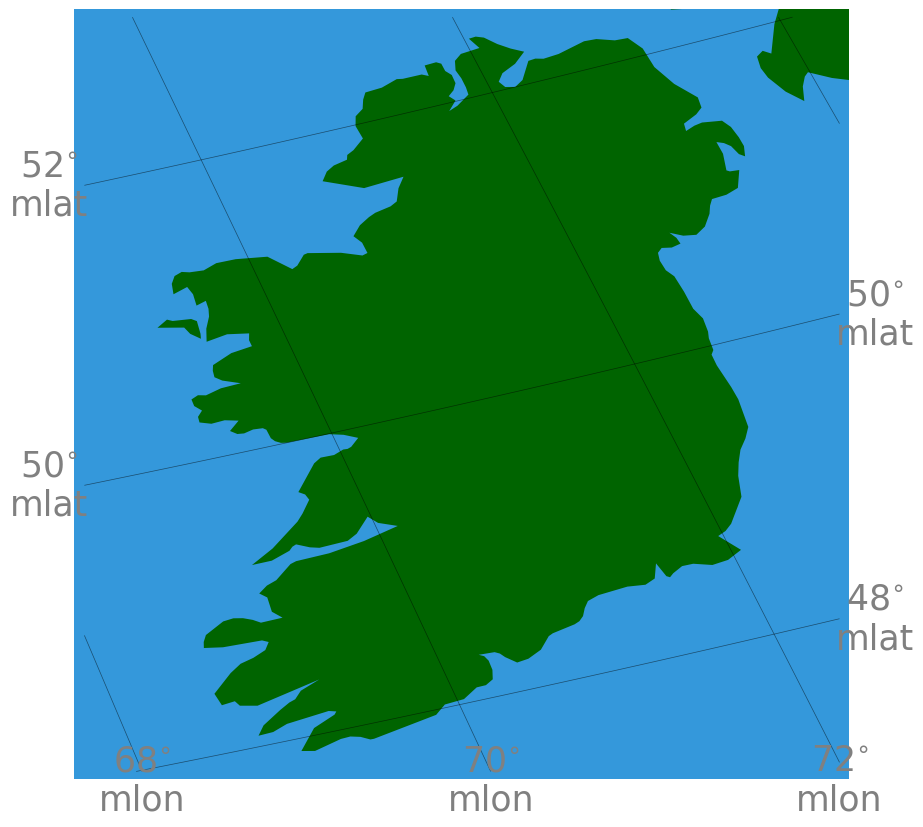

In [40]:
## Find Cubed Sphere Coordinates
mag_locs['xi'], mag_locs['eta']= Gridproj.geo2cube(mag_locs['glon'], mag_locs['glat'])
fig

## Scatter Location

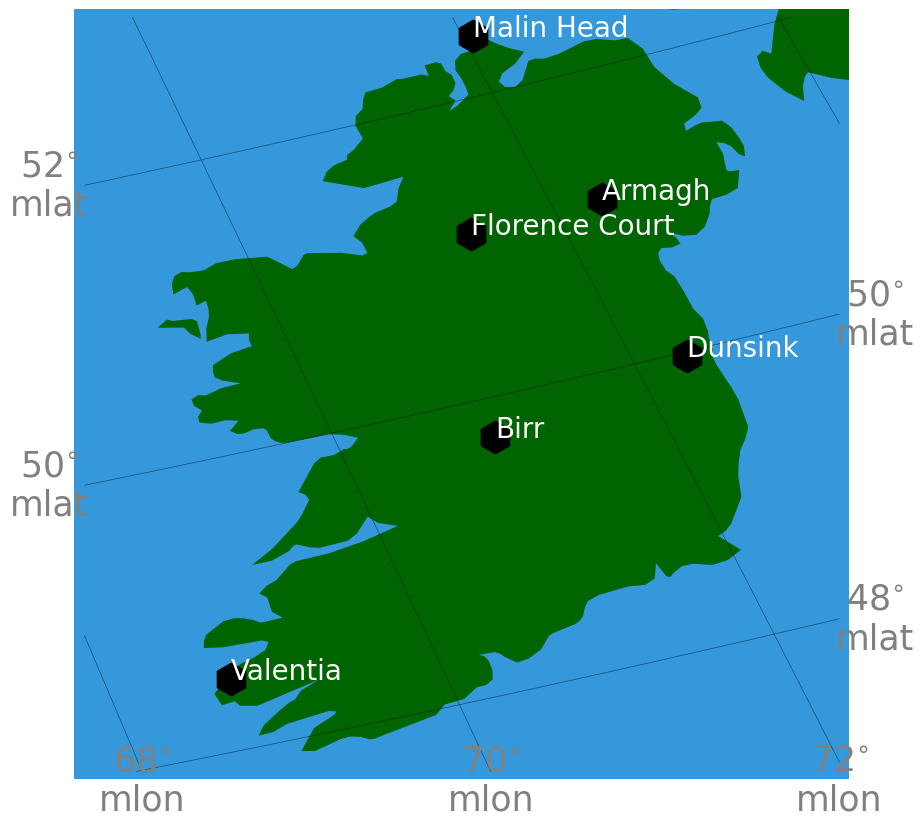

In [ ]:
scat= map_ax.scatter(*Gridproj.geo2cube(mag_locs['glon'], mag_locs['glat']), marker='h', s=500, zorder=10,
                      color='black', facecolor='black', linewidth=2)
for idx, row in mag_locs.iterrows():
    map_ax.text(row['xi'], row['eta'], row['name'], color='white', fontsize=20, zorder=20)
ind= mag_locs['name'].isin(['Valentia', 'Dunsink', 'Florence Court'])
scat2= map_ax.scatter(*Gridproj.geo2cube(mag_locs['glon'], mag_locs['glat']), marker='h', s=500, zorder=10,
                      color='black', facecolor='black', linewidth=2)
fig